In [1]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from transformers import WhisperForAudioClassification, WhisperProcessor
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score, accuracy_score, classification_report, balanced_accuracy_score
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import time
from tqdm import tqdm
import librosa
import random

c:\Users\top\Desktop\shemo_env\shemo_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
if torch.cuda.is_available():
  device = 'cuda'
else:
  device = 'cpu'

device

'cuda'

In [3]:
# Defining a function to set or change the seed for random number generation at each step.

def reset_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available:
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

In [4]:
whisper_large_processor = WhisperProcessor.from_pretrained('whisper_small')

In [5]:
reset_seed(42)
emo2num = {
    'H' : 0,
    'N' : 1,
    'S' : 2,
    'A' : 3,
    'W' : 4
}

num2emo = {
    0 : 'Happy',
    1 : 'Neutral',
    2 : 'Sad',
    3 : 'Anger',
    4 : 'Wonder'
}


audios = []
sample_rates = []
emotions = []
labels = []
features = []

pattern = r'^...(.)'

for root, folders, files in os.walk('shemo'):
    for filename in files:
        file_path = os.path.join(root, filename)
        audio_data, sr = librosa.load(file_path, sr=16000)
        
        input_features = whisper_large_processor(audio_data, sampling_rate=sr, return_tensors="pt").input_features
    

        match = re.search(pattern, filename)
        if match:
            char = match.group(1)
            if char in ['H', 'N', 'S', 'W', 'A']:
                audios.append(audio_data)
                sample_rates.append(sr)
                # emotion = 'H' if char == 'W' else char
                emotion = char
                label = emo2num[emotion]

                emotions.append(emotion)
                labels.append(label)
                features.append(input_features.squeeze(0))

In [6]:
reset_seed(42)
class AudioDataSet(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        # Assuming features[index] is a processed audio feature and labels[index] is the corresponding label
        sample = {
            'feature': torch.Tensor(self.features[index]),  # Convert to PyTorch tensor if not already
            'label': torch.Tensor([self.labels[index]])  # Convert to PyTorch tensor if not already
        }

        return sample
    

Shemo = AudioDataSet(features, labels)


# Split the dataset into training and validation sets
trainset, valset = random_split(Shemo, [len(Shemo)-500, 500])


# Example of using DataLoader for batching
train_loader = DataLoader(trainset, batch_size=4, shuffle=True)
val_loader = DataLoader(valset, batch_size=4, shuffle=False)

In [7]:
reset_seed(42)
def train(model, model_name, optimizer, loss_fn, train_loader, val_loader, epochs =40, patience=4):
  training_losses = []
  valid_losses = []
  durations = []
  best_val_loss = float('inf')
  current_patience = 0

  for epoch in range(epochs):
    training_loss = []
    valid_loss = []
    start_time = time.time()

    model.train()
    for batch in tqdm(train_loader, desc=f'Epoch {epoch}/{epochs}', leave=False): # Each batch, One Iteration
      optimizer.zero_grad()
      inputs, targets = batch['feature'], batch['label'].squeeze(-1).long()
      inputs, targets = inputs.to(device), targets.to(device)
      batch_size = inputs.size(0)
      h = model.init_hidden(batch_size).to(device)
      output = model(inputs, h)
      loss = loss_fn(output, targets)
      loss.backward()
      optimizer.step()
      inputs, targets, output = inputs.to('cpu'), targets.to('cpu'), output.to('cpu') # Return tensors to cpu after each iteration

      training_loss.append(loss.data.item())
    training_loss = np.mean(training_loss)
    training_losses.append(training_loss)
    

    model.eval()
    num_correct = 0
    num_examples = 0
    for batch in tqdm(val_loader, desc=f'Epoch {epoch}/{epochs}', leave=False):
      inputs, targets = batch['feature'], batch['label'].squeeze(-1).long()
      inputs, targets = inputs.to(device), targets.to(device)
      batch_size = inputs.size(0)
      h = model.init_hidden(batch_size).to(device)
      output = model(inputs, h)
      loss = loss_fn(output, targets)
      valid_loss.append(loss.data.item())
      correct = torch.eq(torch.argmax(F.softmax(output, dim=1), dim=1), targets.view(-1))
      num_correct += torch.sum(correct).item()
      num_examples += correct.shape[0]
      inputs, targets, output = inputs.to('cpu'), targets.to('cpu'), output.to('cpu') # Return tensors to cpu after each iteration
      
    valid_loss = np.mean(valid_loss)
    valid_losses.append(valid_loss)
    end_time = time.time()
    duration = end_time - start_time
    durations.append(duration)

    print(f'Epoch: {epoch+1} finished in {duration:.2f} seconds, Training Loss: {training_loss: .2f}, Validation Loss: {valid_loss:.2f}, Validation Accuracy: {num_correct / num_examples : .2f}')

    # Check for improvement
    if valid_loss < best_val_loss:
        best_val_loss = valid_loss
        torch.save(model.state_dict(), f'{model_name}.bin') # Saving the best model because I want to use the best checkpoints of the model to test it
        current_patience = 0
    else:
        current_patience += 1

    # Early stopping logic
    if current_patience >= patience:
        print(f"Early stopping at epoch {epoch+1}. Because Validation loss increased for {patience} consecutive epochs.")
        break

  print(f"Each epoch took {np.mean(durations):.2f} seconds in average.")

  return training_losses, valid_losses

In [8]:
def test(model, loss_fn, test_loader):
  model.eval()
  test_loss = []
  labels = []
  preds = []
  for batch in test_loader:
    inputs, targets = batch['feature'], batch['label'].squeeze(-1).long()

    for target in targets:
      labels.append(target.item())
    inputs, targets = inputs.to(device), targets.to(device)
    batch_size = inputs.size(0)
    h = model.init_hidden(batch_size).to(device)
    output = model(inputs, h)
    for out in output:
      preds.append(torch.argmax(F.softmax(out, dim=0), dim=0).item())
    loss = loss_fn(output, targets)
    test_loss.append(loss.data.item())
    inputs, targets, output = inputs.to('cpu'), targets.to('cpu'), output.to('cpu') # Return tensors to cpu after each iteration


  #######################################################################################################
  accuracy_per_class = {}
  unique_classes = set(labels)
  for class_label in unique_classes:
      indices = [i for i, y in enumerate(labels) if y == class_label]
      class_accuracy = accuracy_score([labels[i] for i in indices], [preds[i] for i in indices])
      accuracy_per_class[class_label] = class_accuracy

  w_acc = sum(accuracy_per_class.values())/len(accuracy_per_class.values())
  #######################################################################################################


  test_loss = np.mean(test_loss)
  w_acc = accuracy_score(labels, preds)
  u_acc = sum(accuracy_per_class.values())/len(accuracy_per_class.values())
  precision = precision_score(labels, preds, average='weighted')
  recall = recall_score(labels, preds, average='weighted')
  f1 = f1_score(labels, preds, average='weighted')
  cm = confusion_matrix(labels, preds)
  sns.set(font_scale=1.2)  # Adjust the font scale for better readability
  sns.heatmap(cm, annot=True, fmt='g', cmap='Greens', 
              xticklabels=['Happy', 'Neutral', 'Sad', 'Anger', 'Wonder'], 
              yticklabels=['Happy', 'Neutral', 'Sad', 'Anger', 'Wonder'])
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.show()

  print(f'Testing finished with Loss: {test_loss: .2f} | U_Accuracy: {u_acc : .2f} | W_Accuracy: {w_acc : .2f} | Precision: {precision : .2f} | Recall: {recall : .2f} | f1: {f1 : .2f}')

  print("Accuracy per class:")
  for class_label, accuracy in accuracy_per_class.items():
      print(f"Class {class_label}: {accuracy}")

In [64]:
reset_seed(42)
whisper_large_path = 'whisper_tiny'
whisper_encoder = WhisperForAudioClassification.from_pretrained(
    whisper_large_path
).encoder

whisper_all = WhisperForAudioClassification.from_pretrained(
    whisper_large_path
)

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_tiny and are newly initialized: ['model.classifier.weight', 'model.classifier.bias', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_tiny and are newly initialized: ['model.classifier.weight', 'model.classifier.bias', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [29]:
whisper_encoder

WhisperEncoder(
  (conv1): Conv1d(80, 384, kernel_size=(3,), stride=(1,), padding=(1,))
  (conv2): Conv1d(384, 384, kernel_size=(3,), stride=(2,), padding=(1,))
  (embed_positions): Embedding(1500, 384)
  (layers): ModuleList(
    (0-3): 4 x WhisperEncoderLayer(
      (self_attn): WhisperSdpaAttention(
        (k_proj): Linear(in_features=384, out_features=384, bias=False)
        (v_proj): Linear(in_features=384, out_features=384, bias=True)
        (q_proj): Linear(in_features=384, out_features=384, bias=True)
        (out_proj): Linear(in_features=384, out_features=384, bias=True)
      )
      (self_attn_layer_norm): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (activation_fn): GELUActivation()
      (fc1): Linear(in_features=384, out_features=1536, bias=True)
      (fc2): Linear(in_features=1536, out_features=384, bias=True)
      (final_layer_norm): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
    )
  )
  (layer_norm): LayerNorm((384,), eps=1e-05, elementw

In [57]:
whisper_encoder

WhisperForAudioClassification(
  (encoder): WhisperEncoder(
    (conv1): Conv1d(80, 384, kernel_size=(3,), stride=(1,), padding=(1,))
    (conv2): Conv1d(384, 384, kernel_size=(3,), stride=(2,), padding=(1,))
    (embed_positions): Embedding(1500, 384)
    (layers): ModuleList(
      (0-3): 4 x WhisperEncoderLayer(
        (self_attn): WhisperSdpaAttention(
          (k_proj): Linear(in_features=384, out_features=384, bias=False)
          (v_proj): Linear(in_features=384, out_features=384, bias=True)
          (q_proj): Linear(in_features=384, out_features=384, bias=True)
          (out_proj): Linear(in_features=384, out_features=384, bias=True)
        )
        (self_attn_layer_norm): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
        (activation_fn): GELUActivation()
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (fc2): Linear(in_features=1536, out_features=384, bias=True)
        (final_layer_norm): LayerNorm((384,), eps=1e-05, elementwise_

In [59]:
print(inspect.getsource(whisper_encoder.forward))

    @add_start_docstrings_to_model_forward(WHISPER_ENCODER_INPUTS_DOCSTRING)
    @replace_return_docstrings(output_type=SequenceClassifierOutput, config_class=_CONFIG_FOR_DOC)
    def forward(
        self,
        input_features: Optional[torch.LongTensor] = None,
        head_mask: Optional[torch.Tensor] = None,
        encoder_outputs: Optional[Tuple[Tuple[torch.FloatTensor]]] = None,
        labels: Optional[torch.LongTensor] = None,
        output_attentions: Optional[bool] = None,
        output_hidden_states: Optional[bool] = None,
        return_dict: Optional[bool] = None,
    ) -> Union[Tuple[torch.Tensor], SequenceClassifierOutput]:
        r"""
        labels (`torch.LongTensor` of shape `(batch_size,)`, *optional*):
            Labels for computing the sequence classification/regression loss. Indices should be in `[0, ...,
            config.num_labels - 1]`. If `config.num_labels == 1` a regression loss is computed (Mean-Square loss), If
            `config.num_labels > 1

In [26]:
import inspect

In [47]:
print(inspect.getsource(whisper_encoder.forward))

    def forward(
        self,
        input_features,
        attention_mask=None,
        head_mask=None,
        output_attentions=None,
        output_hidden_states=None,
        return_dict=None,
    ):
        r"""
        Args:
            input_features (`torch.LongTensor` of shape `(batch_size, feature_size, sequence_length)`):
                Float values of mel features extracted from the raw speech waveform. Raw speech waveform can be
                obtained by loading a `.flac` or `.wav` audio file into an array of type `List[float]` or a
                `numpy.ndarray`, *e.g.* via the soundfile library (`pip install soundfile`). To prepare the array into
                `input_features`, the [`AutoFeatureExtractor`] should be used for extracting the mel features, padding
                and conversion into a tensor of type `torch.FloatTensor`. See [`~WhisperFeatureExtractor.__call__`]
            attention_mask (`torch.Tensor`)`, *optional*):
                Whisper does

In [63]:
whisper_encoder(torch.unsqueeze(features[0], dim=0)).last_hidden_state.shape

torch.Size([1, 1500, 384])

In [69]:
whisper_all.projector(whisper_encoder(torch.unsqueeze(features[0], dim=0)).last_hidden_state).mean(dim=1).shape

torch.Size([1, 256])

In [68]:
whisper_all.projector

Linear(in_features=384, out_features=256, bias=True)

In [19]:
reset_seed(42)

class GRUModel (nn.Module):
  def __init__(self, hidden_size=256, num_layers=1, b_directional=False):
    super(GRUModel, self).__init__()
    self.whisperencoder = WhisperForAudioClassification.from_pretrained('whisper_small').encoder.to(device)
    self.projector = WhisperForAudioClassification.from_pretrained('whisper_small').projector.to(device)
    self.hidden_size = hidden_size
    self.num_layers = num_layers
    if b_directional == True: self.d = 2
    elif b_directional == False: self.d = 1
    self.gru = torch.nn.GRU(256, hidden_size=hidden_size, num_layers=num_layers, bias=True, batch_first=True, dropout=0.0, bidirectional=b_directional, device=device)
    self.classifier = torch.nn.Linear(in_features=self.d*hidden_size, out_features=5)

  def forward(self, x, h0):
    out = self.whisperencoder(x).last_hidden_state
    out = self.projector(out)
    out, _ = self.gru(out, h0)
    out = self.classifier(out[:, -1, :])  # Take the output from the last time step
    return out
  
  def init_hidden(self, batch_size):
    return torch.zeros(self.d * self.num_layers, batch_size, self.hidden_size)

    

In [24]:
reset_seed(42)
model = GRUModel(num_layers=2 ,b_directional=True)

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.weight', 'model.projector.bias', 'model.classifier.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.weight', 'model.projector.bias', 'model.classifier.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [25]:
reset_seed(42)
for param in model.parameters():
    param.requires_grad = False

for param in model.projector.parameters():
    param.requires_grad = True

for param in model.gru.parameters():
    param.requires_grad = True

for param in model.classifier.parameters():
    param.requeres_grad = True

In [26]:
model.to(device)

GRUModel(
  (whisperencoder): WhisperEncoder(
    (conv1): Conv1d(80, 768, kernel_size=(3,), stride=(1,), padding=(1,))
    (conv2): Conv1d(768, 768, kernel_size=(3,), stride=(2,), padding=(1,))
    (embed_positions): Embedding(1500, 768)
    (layers): ModuleList(
      (0-11): 12 x WhisperEncoderLayer(
        (self_attn): WhisperSdpaAttention(
          (k_proj): Linear(in_features=768, out_features=768, bias=False)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (out_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (self_attn_layer_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (activation_fn): GELUActivation()
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
        (final_layer_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)

In [27]:
reset_seed(42)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

training_losses0, valid_losses0 = train(model, 'whisper_gru_b', optimizer, torch.nn.CrossEntropyLoss(), train_loader, val_loader, patience=40)

Epoch: 1 finished in 241.04 seconds, Training Loss:  1.18, Validation Loss: 1.10, Validation Accuracy:  0.64


Epoch: 2 finished in 242.74 seconds, Training Loss:  0.80, Validation Loss: 0.62, Validation Accuracy:  0.81


Epoch: 3 finished in 241.72 seconds, Training Loss:  0.60, Validation Loss: 0.55, Validation Accuracy:  0.81


Epoch: 4 finished in 241.86 seconds, Training Loss:  0.53, Validation Loss: 0.52, Validation Accuracy:  0.84


Epoch: 5 finished in 241.96 seconds, Training Loss:  0.47, Validation Loss: 0.49, Validation Accuracy:  0.84


...

Epoch: 36 finished in 360.13 seconds, Training Loss:  0.18, Validation Loss: 0.51, Validation Accuracy:  0.83


Epoch: 37 finished in 357.27 seconds, Training Loss:  0.15, Validation Loss: 0.49, Validation Accuracy:  0.84


Epoch: 38 finished in 359.84 seconds, Training Loss:  0.15, Validation Loss: 0.54, Validation Accuracy:  0.84


Epoch: 39 finished in 358.57 seconds, Training Loss:  0.18, Validation Loss: 0.52, Validation Accuracy:  0.84


Epoch: 40 finished in 358.47 seconds, Training Loss:  0.19, Validation Loss: 0.56, Validation Accuracy:  0.83
Each epoch took 317.25 seconds in average.


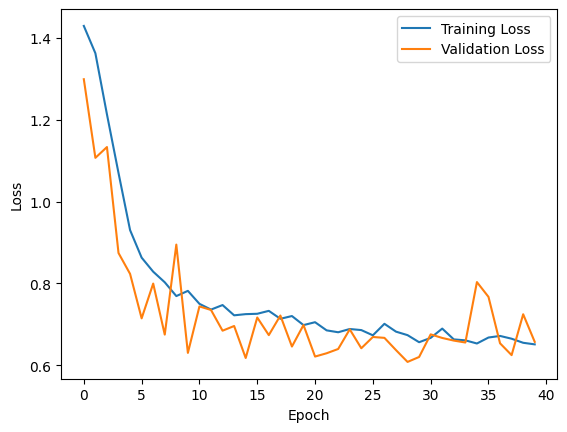

In [104]:
plt.plot(training_losses0, label='Training Loss')
plt.plot(valid_losses0, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

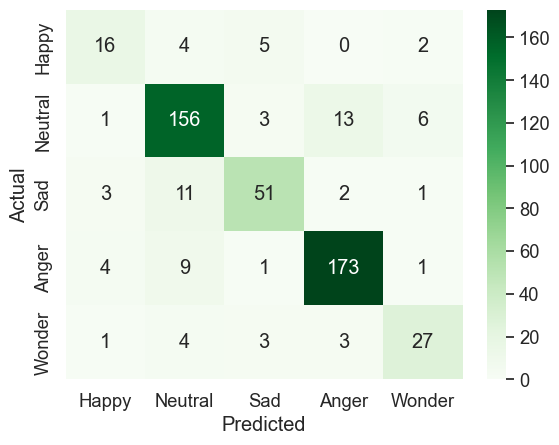

Testing finished with Loss:  0.47 | U_Accuracy:  0.77 | W_Accuracy:  0.85 | Precision:  0.84 | Recall:  0.85 | f1:  0.84
Accuracy per class:
Class 0: 0.5925925925925926
Class 1: 0.8715083798882681
Class 2: 0.75
Class 3: 0.9202127659574468
Class 4: 0.7105263157894737


In [17]:
model.load_state_dict(torch.load('whisper_gru_b.bin'))
test(model, torch.nn.CrossEntropyLoss(), val_loader)